# 💋 Notebook 08 — Lip-Sync Detection (SyncNet-style) ⭐ WOW FACTOR
Person 2

In [3]:
!pip install torch torchvision librosa tqdm scikit-learn -q

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
from PIL import Image
import librosa
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# ── Path (shortcut added to MyDrive root) ──────────────────────────────
BASE_DIR  = "/content/drive/MyDrive/deepfake-project"

# Quick sanity check
assert os.path.exists(BASE_DIR), (
    f"❌ Not found: {BASE_DIR}\n"
    f"MyDrive contains: {os.listdir('/content/drive/MyDrive')}"
)
print("✅ BASE_DIR found:", BASE_DIR)
print("   data/ contents:", os.listdir(os.path.join(BASE_DIR, "data")))

AUDIO_DIR  = os.path.join(BASE_DIR, "data/audio")
MOUTH_DIR  = os.path.join(BASE_DIR, "data/mouth_roi")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32; EPOCHS = 20; LR = 1e-4
MOUTH_SIZE = 96; N_FRAMES = 5; AUDIO_WIN = 0.2; SR = 16000; EMB_DIM = 128; SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"✅ Device: {DEVICE}")

Mounted at /content/drive
✅ BASE_DIR found: /content/drive/MyDrive/deepfake-project
   data/ contents: ['raw', 'frames', 'audio', 'faces', 'mouth_roi', 'spectrograms', 'spectrograms_npy', 'test_videos']
✅ Device: cuda


In [5]:
# ✅ Audio + Visual helpers
mouth_tf = transforms.Compose([
    transforms.Resize((MOUTH_SIZE, MOUTH_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3),
])

def get_mel_segment(wav_path, start_sec, duration=AUDIO_WIN, sr=SR, n_mels=80):
    y, _ = librosa.load(wav_path, sr=sr, offset=start_sec, duration=duration, mono=True)
    pad_len = int(sr*duration)-len(y)
    if pad_len > 0: y = np.pad(y,(0,pad_len))
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min()+1e-8)
    return log_mel.astype(np.float32)

def load_mouth_clip(mouth_frames, n_frames=N_FRAMES):
    clip = []
    idxs = np.linspace(0, len(mouth_frames)-1, n_frames, dtype=int)
    for i in idxs:
        img = Image.open(mouth_frames[i]).convert("RGB")
        clip.append(mouth_tf(img))
    return torch.stack(clip)

print("✅ Helpers defined.")

✅ Helpers defined.


In [6]:
# ✅ Build Sync Pairs Dataset
class LipSyncDataset(Dataset):
    def __init__(self, pairs, n_frames=N_FRAMES):
        self.pairs = pairs; self.n_frames = n_frames
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        audio_path, mouth_frames, start_sec, label = self.pairs[idx]
        audio_seg  = get_mel_segment(audio_path, start_sec)
        mouth_clip = load_mouth_clip(mouth_frames, self.n_frames)
        return (torch.tensor(audio_seg).unsqueeze(0), mouth_clip,
                torch.tensor(label, dtype=torch.float32))

def build_pairs(audio_dir, mouth_dir, split, neg_ratio=1.0):
    a_dir = os.path.join(audio_dir, split)
    m_dir = os.path.join(mouth_dir, split)
    if not os.path.isdir(a_dir) or not os.path.isdir(m_dir): return []
    wavs = list(Path(a_dir).glob("*.wav")); pairs = []
    all_wav_paths = [str(w) for w in wavs]
    for wav in wavs:
        vid_prefix = wav.stem
        m_frames   = sorted(Path(m_dir).glob(f"{vid_prefix}_*.jpg"))
        if len(m_frames) < N_FRAMES: continue
        duration = librosa.get_duration(path=str(wav))
        n_clips  = int(duration / AUDIO_WIN)
        for ci in range(n_clips):
            start  = ci * AUDIO_WIN
            f_start = int(ci/n_clips*len(m_frames)); f_end = min(len(m_frames), f_start+N_FRAMES*4)
            if f_end-f_start < N_FRAMES: continue
            m_clip = [str(f) for f in m_frames[f_start:f_end]]
            pairs.append((str(wav), m_clip, start, 1))
            if random.random() < neg_ratio:
                neg_wav   = random.choice([p for p in all_wav_paths if p != str(wav)])
                neg_dur   = librosa.get_duration(path=neg_wav)
                neg_start = random.uniform(0, max(0, neg_dur-AUDIO_WIN))
                pairs.append((neg_wav, m_clip, neg_start, 0))
    return pairs

all_pairs = []
for split in ["fake_with_audio","real_with_audio"]:
    all_pairs.extend(build_pairs(AUDIO_DIR, MOUTH_DIR, split))
random.shuffle(all_pairs)
n_val = int(len(all_pairs)*0.15)
tr_dl = DataLoader(LipSyncDataset(all_pairs[n_val:]),batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
va_dl = DataLoader(LipSyncDataset(all_pairs[:n_val]),batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
print(f"✅ Pairs — Train: {len(all_pairs)-n_val}, Val: {n_val}")

✅ Pairs — Train: 19464, Val: 3434


In [7]:
# ✅ SyncNet Architecture
class AudioEncoder(nn.Module):
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(80,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256,3,padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(256,emb_dim),
        )
    def forward(self, x): return F.normalize(self.net(x.squeeze(1)), dim=1)

class VideoEncoder(nn.Module):
    def __init__(self, n_frames=N_FRAMES, emb_dim=EMB_DIM):
        super().__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(3,32,(3,5,5),stride=(1,2,2),padding=(1,2,2)),
            nn.BatchNorm3d(32), nn.ReLU(),
        )
        self.conv2d = nn.Sequential(
            nn.Conv2d(32*n_frames,128,3,padding=1), nn.ReLU(),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256,emb_dim),
        )
    def forward(self, x):
        x = x.permute(0,2,1,3,4)
        f = self.conv3d(x); B,C,T,H,W = f.shape
        f = f.reshape(B,C*T,H,W)
        return F.normalize(self.conv2d(f), dim=1)

class SyncNet(nn.Module):
    def __init__(self): super().__init__(); self.audio_enc = AudioEncoder(); self.video_enc = VideoEncoder()
    def forward(self, a, v): return F.cosine_similarity(self.audio_enc(a), self.video_enc(v))

model     = SyncNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print("✅ SyncNet model ready.")

✅ SyncNet model ready.


In [8]:
# ✅ Training
best_auc = 0.0
for epoch in range(1, EPOCHS+1):
    model.train(); tr_loss = 0
    for audio, video, lbl in tqdm(tr_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        audio, video, lbl = audio.to(DEVICE), video.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(audio,video), lbl)
        loss.backward(); optimizer.step(); tr_loss += loss.item()
    scheduler.step()
    model.eval(); probs, lbls_all = [], []
    with torch.no_grad():
        for audio, video, lbl in va_dl:
            sim = torch.sigmoid(model(audio.to(DEVICE), video.to(DEVICE)))
            probs.extend(sim.cpu().numpy()); lbls_all.extend(lbl.numpy())
    auc = roc_auc_score(lbls_all, probs)
    acc = accuracy_score(lbls_all, [p>0.5 for p in probs])
    print(f"  Epoch {epoch}: loss={tr_loss/len(tr_dl):.4f}  val_acc={acc:.4f}  val_auc={auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR,"lipsync_net.pth"))
        print("  ✔ Saved best model")
print(f"\n✅ Done. Best AUC: {best_auc:.4f}")

Epoch 1/20: 100%|██████████| 609/609 [15:12<00:00,  1.50s/it]


  Epoch 1: loss=0.6484  val_acc=0.6773  val_auc=0.7273
  ✔ Saved best model


Epoch 2/20: 100%|██████████| 609/609 [07:21<00:00,  1.38it/s]


  Epoch 2: loss=0.6069  val_acc=0.6890  val_auc=0.7601
  ✔ Saved best model


Epoch 3/20: 100%|██████████| 609/609 [07:19<00:00,  1.39it/s]


...

  Epoch 18: loss=0.5216  val_acc=0.7446  val_auc=0.8485


Epoch 19/20: 100%|██████████| 609/609 [07:11<00:00,  1.41it/s]


  Epoch 19: loss=0.5217  val_acc=0.7510  val_auc=0.8509
  ✔ Saved best model


Epoch 20/20: 100%|██████████| 609/609 [07:10<00:00,  1.41it/s]


  Epoch 20: loss=0.5198  val_acc=0.7507  val_auc=0.8523
  ✔ Saved best model

✅ Done. Best AUC: 0.8523


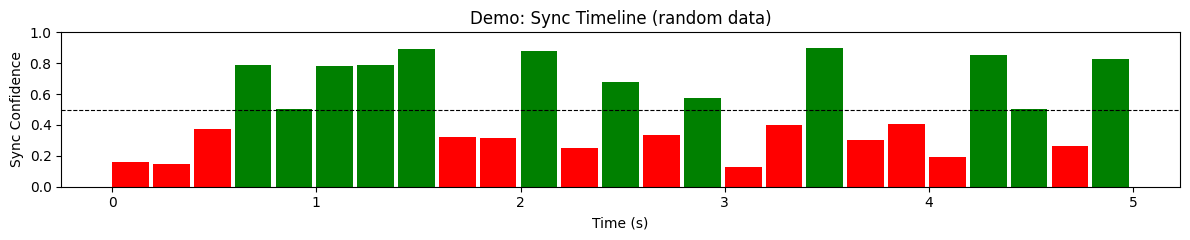

✅ Lip-Sync model training complete.


In [9]:
# ✅ Sync Score Timeline Demo
def plot_sync_timeline(results, title="Lip-Sync Confidence"):
    times  = [r[0] for r in results]; scores = [r[1] for r in results]
    colors = ["red" if s<0.5 else "green" for s in scores]
    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.bar(times, scores, width=AUDIO_WIN*0.9, color=colors, align="edge")
    ax.axhline(0.5,color="black",linestyle="--",linewidth=0.8)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Sync Confidence")
    ax.set_ylim(0,1); ax.set_title(title); plt.tight_layout(); plt.show()

# Demo with dummy values (replace with real inference on a video)
demo_results = [(i*0.2, random.uniform(0.1,0.9)) for i in range(25)]
plot_sync_timeline(demo_results, "Demo: Sync Timeline (random data)")
print("✅ Lip-Sync model training complete.")